In [36]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset, Normalize
from src.data.data_loader import get_data_loaders
from src.models.crnn import CRNN
from src.models.loss_fn import RangeNormalizedMAE, RangeNormalizedMSE
# For one step reaction
y0_onestep = {
    'S_1' : (20, 60),
    'S_2' : (100, 100),
    'S_out' : (0, 0),
}

y0_latent = {
    'S_1' : (20, 60),
    'S_2' : (100, 100),
    'S_3' : (0, 0),
    'S_4' : (0, 0),
    'S_out' : (0, 0),
}
ks_onestep = [2e4*1e-9]
ks_latent = [2e4*1e-9, 4e7*1e-9]

time_hours = 1 #hours
t_end = time_hours * 3600  # seconds



data_gen_one_step = SyntheticDataGenerator(
    mechanism='one_step',
    reaction_rates=ks_onestep,
    initial_concentration_ranges=y0_onestep,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
)

data_gen_latent = SyntheticDataGenerator(
    mechanism='one_step_1latent',
    reaction_rates=ks_latent,
    initial_concentration_ranges=y0_latent,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
)

[[442.10952907]]


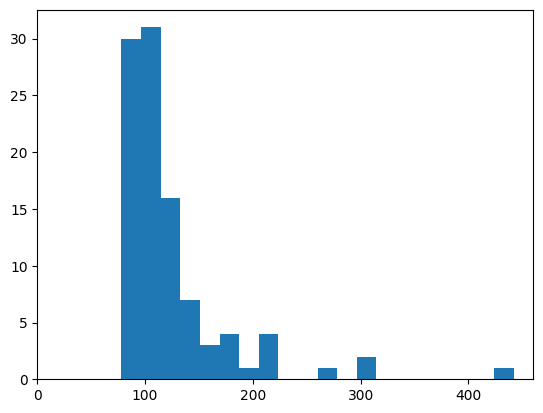

Best c0: (np.float64(1.0), np.float64(1.0), 0)
Best FIM value: 442.1095290662659


In [37]:
import itertools
density = 10
c_maxs = [100, 100, 0]
num_nonzeros = len([i for i, c in enumerate(c_maxs) if c > 0])
c_ranges = [np.linspace(1, c_max, density) if not c_max == 0 else [0] for c_max in c_maxs ]
all_c0 = list(itertools.product(*c_ranges))


outs = []
first = True
for c0 in all_c0:
    C, fim = data_gen_one_step._compute_fim_output(c0)
    if first:
        print(data_gen_one_step._compute_fim_output(c0)[1])
        first = False
    outs.append(fim[0][0])
    
    
best_ind = np.argmax(outs)
c_best = all_c0[best_ind]
fim_best = outs[best_ind]

bin_factor = density//2
plt.hist(outs, bins = (density**num_nonzeros)//bin_factor)
plt.xlim(0,)
plt.show()
print("Best c0:", c_best)
print("Best FIM value:", fim_best)

In [ ]:
import itertools
density = 10
c_maxs = [100, 100, 0, 0, 0]
num_nonzeros = len([i for i, c in enumerate(c_maxs) if c > 0])
c_ranges = [np.linspace(1, c_max, density) if not c_max == 0 else [0] for c_max in c_maxs ]

all_c0 = list(itertools.product(*c_ranges))

outs = []
first = True
for c0 in all_c0:
    C, fim = data_gen_latent._compute_fim_output(c0)
    if first:
        print(data_gen_latent._compute_fim_output(c0)[1])
        first = False
    d = np.linalg.det(fim)
    
    outs.append(d)
    

best_ind = np.argmax(outs)
c_best = all_c0[best_ind]
fim_best = outs[best_ind]

bin_factor = density//2
plt.hist(outs, bins = (density**num_nonzeros)//bin_factor)
plt.xlim(0,)
plt.show()
print("Best c0:", c_best)
print("Best FIM value:", fim_best)

[[4.33217863e+02 4.63723678e+00]
 [4.63723678e+00 6.68434914e-02]]
